### 각각의 지표들이 신용 위험을 얼마나, 선제적으로 잘 반영하는지를 확인 
- regime 분류 지표료 사용할 예정


1. **OAS Z-Score (아이디어 4)**: 신용 위험의 '수준'을 통계적으로 보여주는 가장 직접적인 지표.
2. **Price Percentile (아이디어 2)**: SHYG 가격이 과거 대비 얼마나 낮은지를 보여주는 '가격' 기반 지표.
3. **Credit Volatility (아이디어 3)**: SHYG와 IEF의 상대 변동성으로 시장 불안감을 측정하는 '변동성' 기반 지표.
4. **DTS (아이디어 5)**: 듀레이션과 OAS를 결합하여 위험의 크기를 측정하는 '하이브리드' 지표.
5. **Drawdown Intensity (아이디어 5)**: 최근 6개월간의 최대 하락폭으로 시장의 '고통' 강도를 측정하는 지표.

## 1단계: 데이터 준비 및 5가지 위험 신호 계산

In [2]:
# --- 1. 데이터 준비 및 신호 계산 ---
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred

# 한글 폰트 설정
try:
    import platform
    if platform.system() == 'Darwin': plt.rc('font', family='AppleGothic')
    elif platform.system() == 'Windows': plt.rc('font', family='Malgun Gothic')
    else: plt.rc('font', family='NanumGothic')
except ImportError: pass
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로딩 (GFC를 포함하기 위해 2007년부터)
tickers = ['SHYG', 'HYG', 'IEF'] # HYG는 SHYG 이전 데이터 보완용
start_date = '2007-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']

# SHYG가 상장되기 전까지 HYG 데이터로 대체하여 긴 시계열 확보
etf_data['HY_Price'] = etf_data['SHYG'].combine_first(etf_data['HYG'])

# FRED API 키를 입력하세요
api_key = 'f75d683dda2053416b64caae44e1bfb2'
fred = Fred(api_key=api_key)
oas_data = fred.get_series('BAMLH0A0HYM2', start_date=start_date, end_date=end_date)
oas_data.name = 'OAS'

# 데이터 통합 및 전처리
df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()
daily_returns = df[['HY_Price', 'IEF']].pct_change()

# --- 5가지 위험 신호 계산 ---
signals_df = pd.DataFrame(index=df.index)

# 1. OAS Z-Score
signals_df['OAS_Z'] = (df['OAS'] - df['OAS'].mean()) / df['OAS'].std()

# 2. Price Percentile (1 - Percentile Rank, 1년 롤링) 
price_percentile = df['HY_Price'].rolling(252).apply(lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False)
signals_df['Price_Percentile_Risk'] = 1 - price_percentile # 가격이 낮을수록 위험도(값)가 높게

# 3. Credit Volatility (HY/IEF 변동성 비율, 3개월 롤링)
vol_hy = daily_returns['HY_Price'].rolling(63).std()
vol_ief = daily_returns['IEF'].rolling(63).std()
signals_df['Credit_Volatility'] = vol_hy / vol_ief

# 4. DTS (Duration-Times-Spread)
D_SHYG = 2.1 # SHYG 듀레이션 가정
signals_df['DTS'] = df['OAS'] * D_SHYG

# 5. Drawdown Intensity (6개월 롤링 MDD)
def rolling_mdd(x):
    return (x / x.expanding().max() - 1).min()

signals_df['Drawdown_Intensity'] = df['HY_Price'].rolling(126).apply(rolling_mdd, raw=False).abs()

# 모든 신호를 Z-Score로 표준화하여 비교
signals_df.dropna(inplace=True)
normalized_signals = (signals_df - signals_df.mean()) / signals_df.std()

print("5가지 위험 신호 계산 완료.")

/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_7711/1238554276.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  3 of 3 completed

/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_7711/1238554276.py:34: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()
/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_7711/1238554276.py:34: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()


5가지 위험 신호 계산 완료.


In [11]:
signals_df

,OAS_Z,Price_Percentile_Risk,Credit_Volatility,DTS,Drawdown_Intensity
2014-10-16,0.647594,0.857143,0.697282,10.458,0.030965
2014-10-17,0.385045,0.692460,0.801535,9.828,0.030965
2014-10-20,0.385045,0.539683,0.821265,9.828,0.030965
2014-10-21,0.227516,0.648810,0.820710,9.450,0.030965
2014-10-22,0.175006,0.527778,0.844448,9.324,0.030965
...,...,...,...,...,...
2025-09-23,-1.339025,0.003968,0.506626,5.691,0.040618
2025-09-24,-1.347777,0.017857,0.504944,5.670,0.037718
2025-09-25,-1.295267,0.039683,0.514240,5.796,0.037718
2025-09-26,-1.304018,0.029762,0.519284,5.775,0.037718


In [10]:
normalized_signals

,OAS_Z,Price_Percentile_Risk,Credit_Volatility,DTS,Drawdown_Intensity
2014-10-16,0.601044,1.825063,-0.242650,0.601044,-0.180219
2014-10-17,0.348187,1.331761,-0.002737,0.348187,-0.180219
2014-10-20,0.348187,0.874118,0.042668,0.348187,-0.180219
2014-10-21,0.196473,1.201006,0.041390,0.196473,-0.180219
2014-10-22,0.145902,0.838458,0.096018,0.145902,-0.180219
...,...,...,...,...,...
2025-09-23,-1.312237,-0.730601,-0.681401,-1.312237,0.071056
2025-09-24,-1.320666,-0.688997,-0.685273,-1.320666,-0.004435
2025-09-25,-1.270095,-0.623619,-0.663881,-1.270095,-0.004435
2025-09-26,-1.278523,-0.653336,-0.652273,-1.278523,-0.004435


## 2단계: 신호 간 상관관계 분석

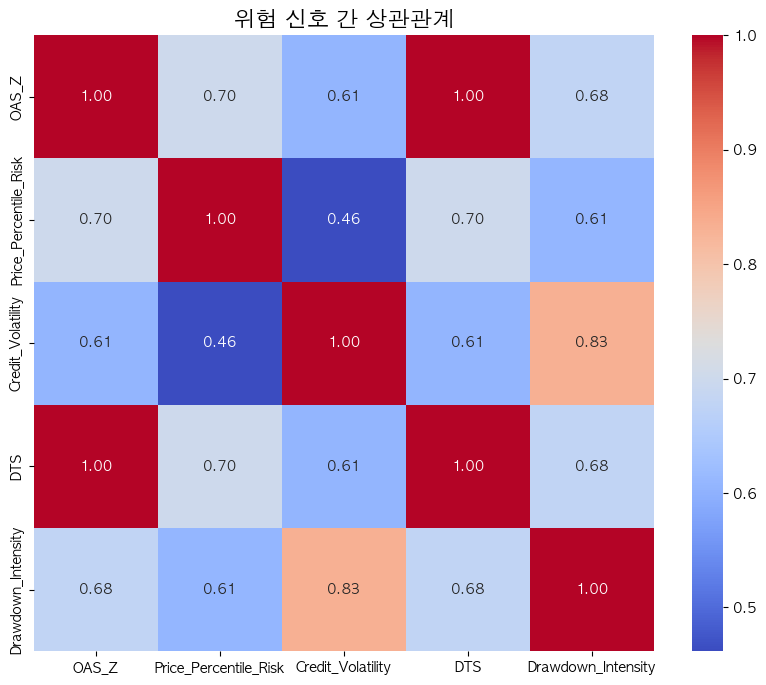


--- 상관관계 분석 결과 ---
                          OAS_Z  Price_Percentile_Risk  Credit_Volatility  \
OAS_Z                  1.000000               0.699886           0.606195   
Price_Percentile_Risk  0.699886               1.000000           0.461683   
Credit_Volatility      0.606195               0.461683           1.000000   
DTS                    1.000000               0.699886           0.606195   
Drawdown_Intensity     0.678709               0.607918           0.833094   

                            DTS  Drawdown_Intensity  
OAS_Z                  1.000000            0.678709  
Price_Percentile_Risk  0.699886            0.607918  
Credit_Volatility      0.606195            0.833094  
DTS                    1.000000            0.678709  
Drawdown_Intensity     0.678709            1.000000  


In [3]:
# --- 2. 상관관계 분석 ---
correlation_matrix = normalized_signals.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('위험 신호 간 상관관계', fontsize=16)
plt.show()

print("\n--- 상관관계 분석 결과 ---")
print(correlation_matrix)

In [6]:
correlation_matrix.round(2)

,OAS_Z,Price_Percentile_Risk,Credit_Volatility,DTS,Drawdown_Intensity
OAS_Z,1.00,0.70,0.61,1.00,0.68
Price_Percentile_Risk,0.70,1.00,0.46,0.70,0.61
Credit_Volatility,0.61,0.46,1.00,0.61,0.83
DTS,1.00,0.70,0.61,1.00,0.68
Drawdown_Intensity,0.68,0.61,0.83,0.68,1.00


## 3단계: 위기 국면 시각화

### 위험판별

- '유가 폭락': ('2015-08-01', '2016-02-29'),
- '코로나19': ('2020-02-20', '2020-04-30'),
- '2022 긴축': ('2022-01-01', '2022-12-31')

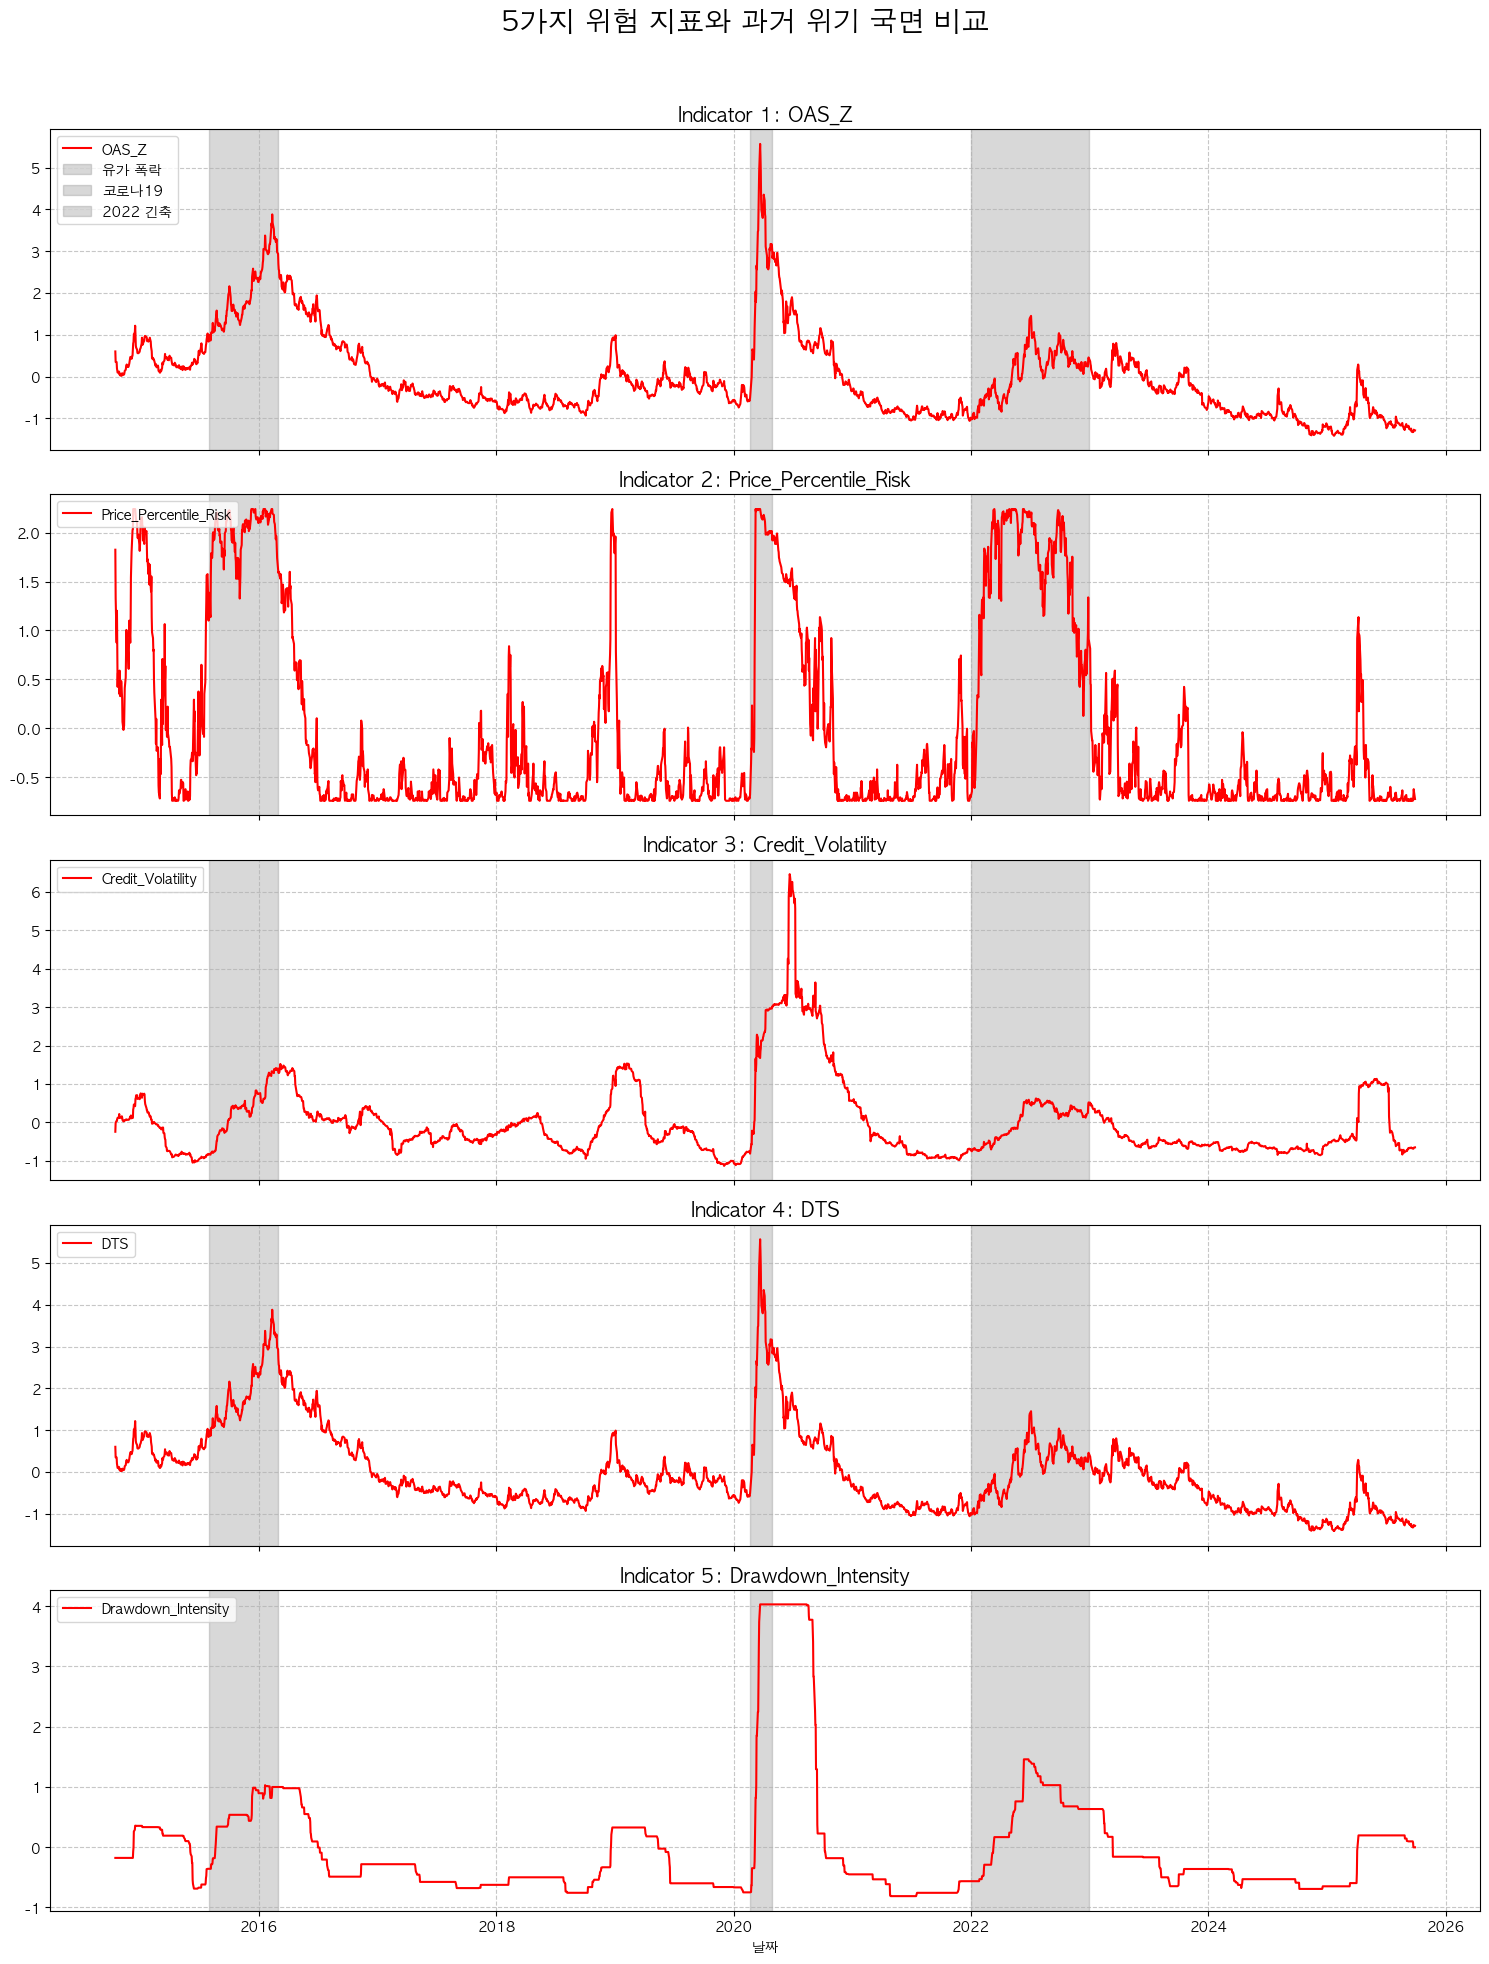

In [9]:
# --- 3. 위기 국면 시각화 ---
crisis_periods = {
    
    '유가 폭락': ('2015-08-01', '2016-02-29'),
    '코로나19': ('2020-02-20', '2020-04-30'),
    '2022 긴축': ('2022-01-01', '2022-12-31')
}

fig, axes = plt.subplots(5, 1, figsize=(15, 20), sharex=True)
fig.suptitle('5가지 위험 지표와 과거 위기 국면 비교', fontsize=20)

indicators_to_plot = normalized_signals.columns
for i, ax in enumerate(axes):
    indicator = indicators_to_plot[i]
    ax.plot(normalized_signals.index, normalized_signals[indicator], label=indicator, color='red')
    
    for name, (start, end) in crisis_periods.items():
        ax.axvspan(start, end, color='gray', alpha=0.3, label=name if i == 0 else "")
        
    ax.set_title(f'Indicator {i+1}: {indicator}', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='upper left')

plt.xlabel('날짜')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 각각의 신호 조합 레짐 판별

- OAS - Z Score를 무조건  포함하도록

/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_7711/1059695462.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  3 of 3 completed
/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_7711/1059695462.py:31: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()


5가지 위험 신호 계산 완료.


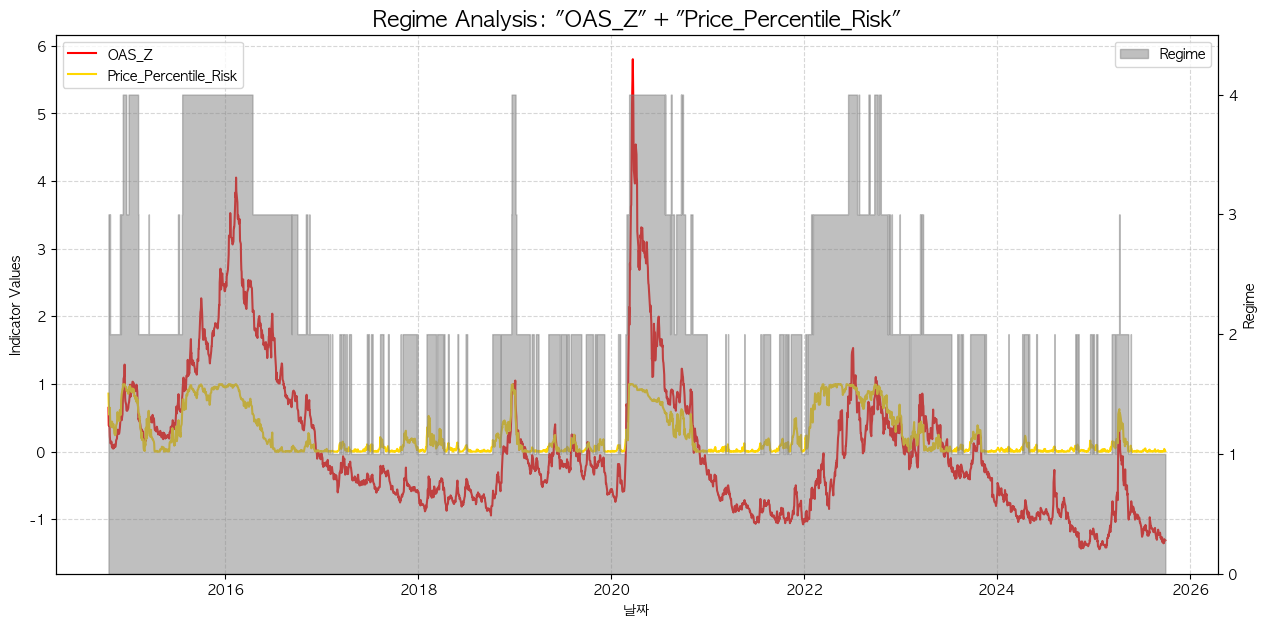

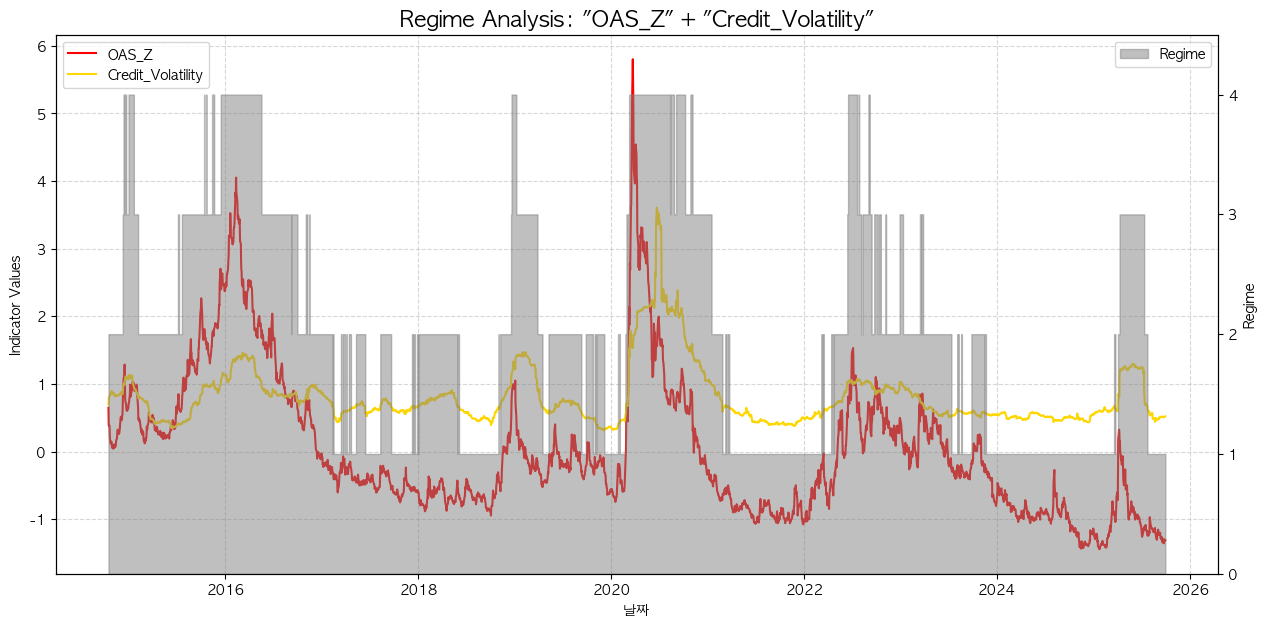

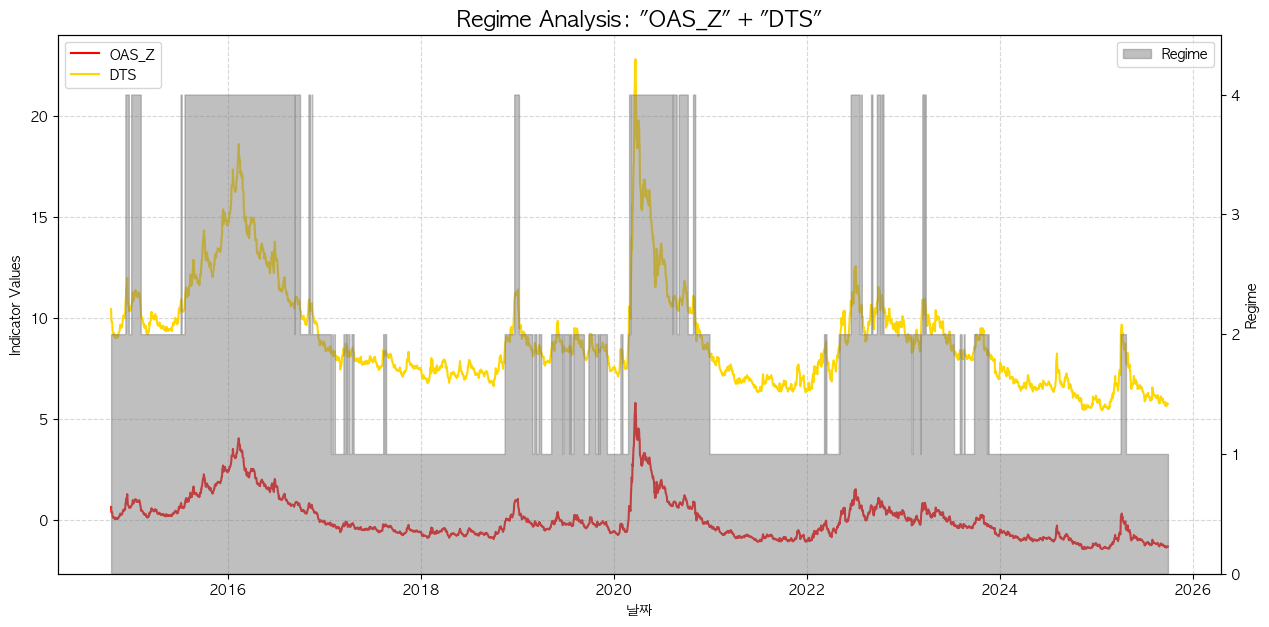

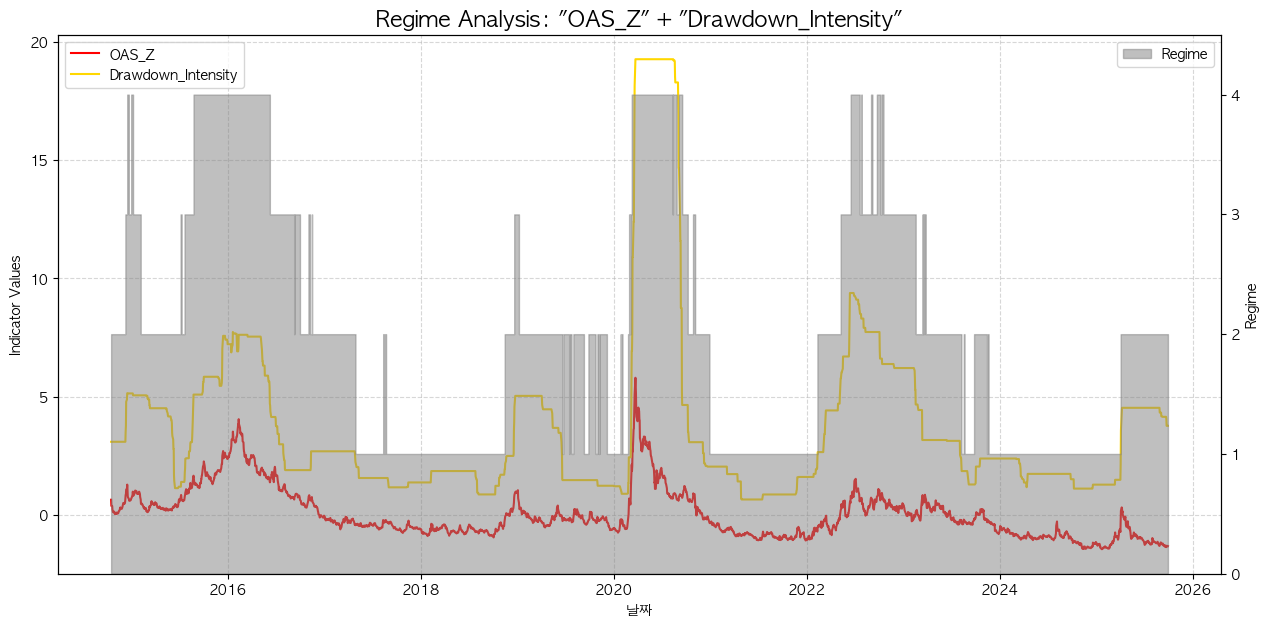

In [12]:
# --- 1단계: 데이터 준비 및 5가지 위험 신호 계산 (이전 코드 재사용) ---
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred

# 한글 폰트 설정
try:
    import platform
    if platform.system() == 'Darwin': plt.rc('font', family='AppleGothic')
    elif platform.system() == 'Windows': plt.rc('font', family='Malgun Gothic')
    else: plt.rc('font', family='NanumGothic')
except ImportError: pass
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로딩 (GFC를 포함하기 위해 2007년부터)
tickers = ['SHYG', 'HYG', 'IEF']
start_date = '2007-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']
etf_data['HY_Price'] = etf_data['SHYG'].combine_first(etf_data['HYG'])

# FRED API 키를 입력하세요
api_key = 'f75d683dda2053416b64caae44e1bfb2'
fred = Fred(api_key=api_key)
oas_data = fred.get_series('BAMLH0A0HYM2', start_date=start_date, end_date=end_date)
oas_data.name = 'OAS'

df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()
daily_returns = df[['HY_Price', 'IEF']].pct_change()

# 5가지 위험 신호 계산 (Z-score 표준화 이전의 원본 값을 사용)
signals_df = pd.DataFrame(index=df.index)
signals_df['OAS_Z'] = (df['OAS'] - df['OAS'].mean()) / df['OAS'].std()
price_percentile = df['HY_Price'].rolling(252).apply(lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False)
signals_df['Price_Percentile_Risk'] = 1 - price_percentile
vol_hy = daily_returns['HY_Price'].rolling(63).std() * np.sqrt(252)
vol_ief = daily_returns['IEF'].rolling(63).std() * np.sqrt(252)
signals_df['Credit_Volatility'] = vol_hy / vol_ief
D_SHYG = 2.1
signals_df['DTS'] = df['OAS'] * D_SHYG
def rolling_mdd(x):
    return (x / x.expanding().max() - 1).min()
signals_df['Drawdown_Intensity'] = df['HY_Price'].rolling(126).apply(rolling_mdd, raw=False).abs() * 100
signals_df.dropna(inplace=True)

print("5가지 위험 신호 계산 완료.")


# --- 2단계: 레짐 정의 및 계산 함수 ---
def calculate_regime(indicator1, indicator2, p50_1, p80_1, p50_2, p80_2):
    if indicator1 > p80_1 and indicator2 > p80_2:
        return 4 # Very Risk-off
    elif indicator1 > p80_1 or indicator2 > p80_2:
        return 3 # Risk-off
    elif indicator1 > p50_1 or indicator2 > p50_2:
        return 2 # Risk-on (Neutral)
    else:
        return 1 # Very Risk-on

# --- 3단계: OAS_Z를 기준으로 한 지표 조합 그래프 생성 ---
# [수정] OAS_Z를 기준으로 다른 지표들을 조합
indicator_pairs = [
    ('OAS_Z', 'Price_Percentile_Risk'),
    ('OAS_Z', 'Credit_Volatility'),
    ('OAS_Z', 'DTS'),
    ('OAS_Z', 'Drawdown_Intensity')
]

for ind1_name, ind2_name in indicator_pairs:
    
    # 레짐 계산
    # 각 지표의 50%, 80% 분위수를 기준으로 레짐을 나눔
    p50_1, p80_1 = signals_df[ind1_name].quantile([0.5, 0.8])
    p50_2, p80_2 = signals_df[ind2_name].quantile([0.5, 0.8])
    
    regime_series = [calculate_regime(row[ind1_name], row[ind2_name], p50_1, p80_1, p50_2, p80_2) for index, row in signals_df.iterrows()]
    signals_df['Regime'] = regime_series
    
    # 시각화
    fig, ax1 = plt.subplots(figsize=(15, 7))
    
    # 좌측 Y축: 두 가지 지표
    ax1.plot(signals_df.index, signals_df[ind1_name], color='red', label=ind1_name)
    ax1.plot(signals_df.index, signals_df[ind2_name], color='gold', label=ind2_name)
    ax1.set_xlabel('날짜')
    ax1.set_ylabel(f'Indicator Values')
    ax1.legend(loc='upper left')
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # 우측 Y축: 레짐
    ax2 = ax1.twinx()
    ax2.fill_between(signals_df.index, 0, signals_df['Regime'], step='post', color='gray', alpha=0.5, label='Regime')
    ax2.set_ylabel('Regime')
    ax2.set_yticks([0, 1, 2, 3, 4])
    ax2.set_ylim(0, 4.5)
    ax2.legend(loc='upper right')

    plt.title(f'Regime Analysis: "{ind1_name}" + "{ind2_name}"', fontsize=16)
    plt.show()

/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_7711/2109569083.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  3 of 3 completed
/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_7711/2109569083.py:31: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()


5가지 위험 신호 계산 완료.


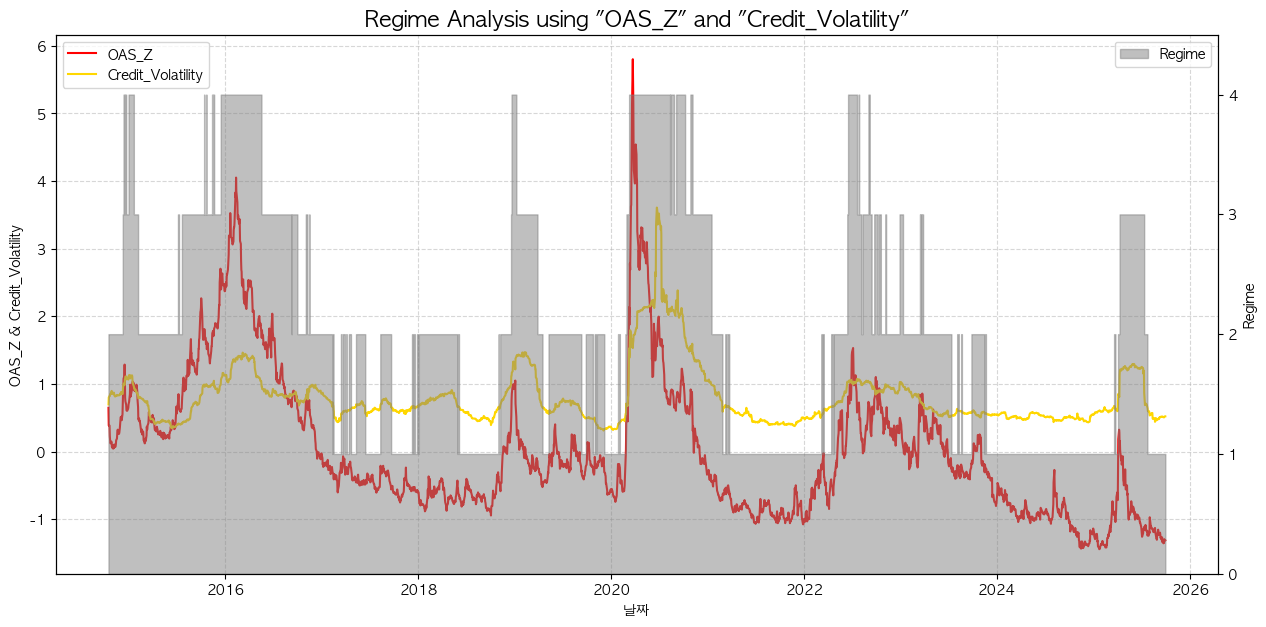

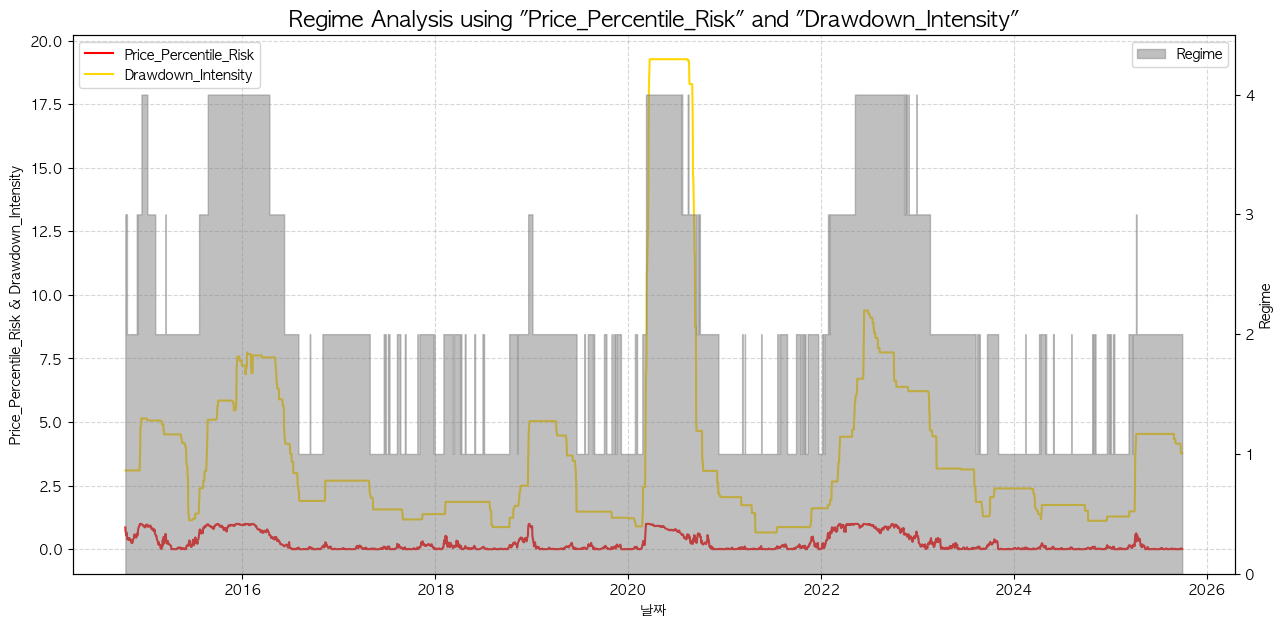

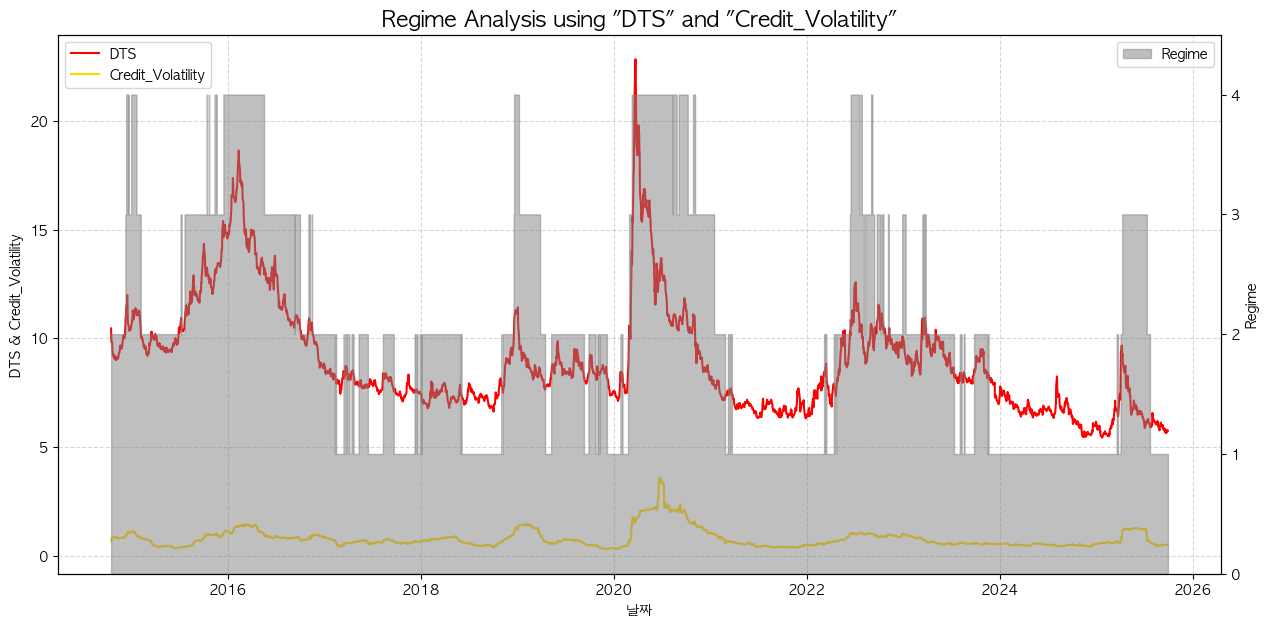

In [13]:
# --- 1단계: 데이터 준비 및 5가지 위험 신호 계산 (이전 코드 재사용) ---
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred

# 한글 폰트 설정
try:
    import platform
    if platform.system() == 'Darwin': plt.rc('font', family='AppleGothic')
    elif platform.system() == 'Windows': plt.rc('font', family='Malgun Gothic')
    else: plt.rc('font', family='NanumGothic')
except ImportError: pass
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로딩 (GFC를 포함하기 위해 2007년부터)
tickers = ['SHYG', 'HYG', 'IEF']
start_date = '2007-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']
etf_data['HY_Price'] = etf_data['SHYG'].combine_first(etf_data['HYG'])

# FRED API 키를 입력하세요
api_key = 'f75d683dda2053416b64caae44e1bfb2'
fred = Fred(api_key=api_key)
oas_data = fred.get_series('BAMLH0A0HYM2', start_date=start_date, end_date=end_date)
oas_data.name = 'OAS'

df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()
daily_returns = df[['HY_Price', 'IEF']].pct_change()

# 5가지 위험 신호 계산 (Z-score 표준화 이전의 원본 값을 사용)
signals_df = pd.DataFrame(index=df.index)
signals_df['OAS_Z'] = (df['OAS'] - df['OAS'].mean()) / df['OAS'].std()
price_percentile = df['HY_Price'].rolling(252).apply(lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False)
signals_df['Price_Percentile_Risk'] = 1 - price_percentile
vol_hy = daily_returns['HY_Price'].rolling(63).std() * np.sqrt(252) # 연율화
vol_ief = daily_returns['IEF'].rolling(63).std() * np.sqrt(252) # 연율화
signals_df['Credit_Volatility'] = vol_hy / vol_ief
D_SHYG = 2.1
signals_df['DTS'] = df['OAS'] * D_SHYG
def rolling_mdd(x):
    return (x / x.expanding().max() - 1).min()
signals_df['Drawdown_Intensity'] = df['HY_Price'].rolling(126).apply(rolling_mdd, raw=False).abs() * 100 # % 단위로 변경
signals_df.dropna(inplace=True)

print("5가지 위험 신호 계산 완료.")


# --- 2단계: 레짐 정의 및 계산 함수 ---
def calculate_regime(indicator1, indicator2, p50_1, p80_1, p50_2, p80_2):
    if indicator1 > p80_1 and indicator2 > p80_2:
        return 4 # Very Risk-off
    elif indicator1 > p80_1 or indicator2 > p80_2:
        return 3 # Risk-off
    elif indicator1 > p50_1 or indicator2 > p50_2:
        return 2 # Risk-on (Neutral)
    else:
        return 1 # Very Risk-on

# --- 3단계: 대표적인 지표 조합 3가지에 대한 그래프 생성 ---
indicator_pairs = [
    ('OAS_Z', 'Credit_Volatility'),
    ('Price_Percentile_Risk', 'Drawdown_Intensity'),
    ('DTS', 'Credit_Volatility')
]

for ind1_name, ind2_name in indicator_pairs:
    
    # 레짐 계산
    p50_1, p80_1 = signals_df[ind1_name].quantile([0.5, 0.8])
    p50_2, p80_2 = signals_df[ind2_name].quantile([0.5, 0.8])
    
    regime_series = [calculate_regime(row[ind1_name], row[ind2_name], p50_1, p80_1, p50_2, p80_2) for index, row in signals_df.iterrows()]
    signals_df['Regime'] = regime_series
    
    # 시각화
    fig, ax1 = plt.subplots(figsize=(15, 7))
    
    # 좌측 Y축: 두 가지 지표
    ax1.plot(signals_df.index, signals_df[ind1_name], color='red', label=ind1_name)
    ax1.plot(signals_df.index, signals_df[ind2_name], color='gold', label=ind2_name)
    ax1.set_xlabel('날짜')
    ax1.set_ylabel(f'{ind1_name} & {ind2_name}')
    ax1.legend(loc='upper left')
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # 우측 Y축: 레짐
    ax2 = ax1.twinx()
    # 레퍼런스와 유사하게 fill_between으로 영역 표시
    ax2.fill_between(signals_df.index, 0, signals_df['Regime'], step='post', color='gray', alpha=0.5, label='Regime')
    ax2.set_ylabel('Regime')
    ax2.set_yticks([0, 1, 2, 3, 4])
    ax2.set_ylim(0, 4.5)
    ax2.legend(loc='upper right')

    plt.title(f'Regime Analysis using "{ind1_name}" and "{ind2_name}"', fontsize=16)
    plt.show()

/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_7711/479829486.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  5 of 5 completed
/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_7711/479829486.py:33: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()


--- 1. 데이터 준비 완료 ---
--- 1. 데이터 준비 완료 ---

--- 2. Neutral 포트폴리오 최적화 완료 (듀레이션: 3.33년) ---

--- 3. 월별 레짐 및 목표 듀레이션 생성 완료 ---

--- 4. 백테스팅 완료 ---

--- 5. 최종 성과 지표 비교 ---
             CAGR (%)  Volatility (%)  Sharpe Ratio  MDD (%)  Calmar Ratio
전술적 듀레이션 틸트      3.70            4.98          0.74   -13.48          0.27
벤치마크 (AGG)       2.05            5.09          0.40   -18.43          0.11


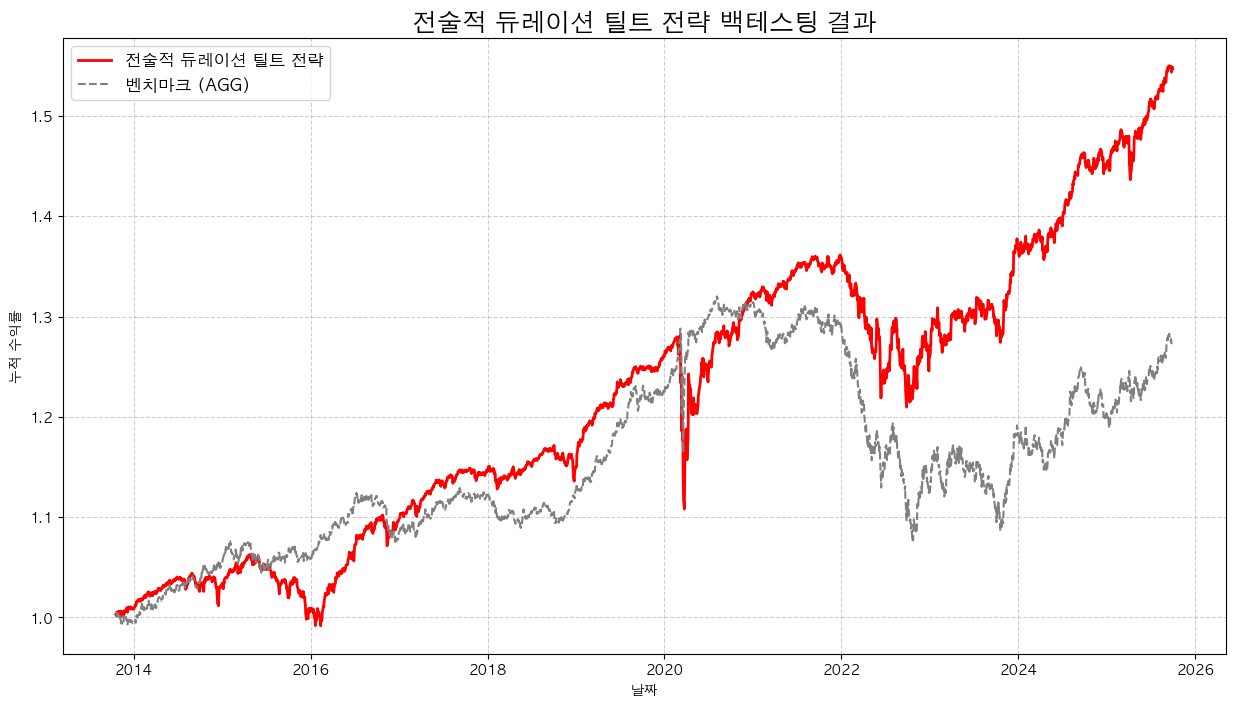

In [36]:
# --- 1단계: 데이터 준비 (오류 수정) ---
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
from scipy.optimize import minimize

# 한글 폰트 설정
try:
    import platform
    if platform.system() == 'Darwin': plt.rc('font', family='AppleGothic')
    elif platform.system() == 'Windows': plt.rc('font', family='Malgun Gothic')
    else: plt.rc('font', family='NanumGothic')
except ImportError: pass
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로딩
tickers = ['SHYG', 'HYG', 'IEF', 'TLT', 'AGG']
start_date = '2007-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
# [수정] yf.download()의 end_date를 end로 변경, 'Close' 대신 'Adj Close' 사용 권장
etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']
etf_data['HY_Price'] = etf_data['SHYG'].combine_first(etf_data['HYG'])

# FRED API 키를 입력하세요
api_key = 'f75d683dda2053416b64caae44e1bfb2'
fred = Fred(api_key=api_key)
oas_data = fred.get_series('BAMLH0A0HYM2', start_date=start_date, end_date=end_date)
oas_data.name = 'OAS'

# 데이터 통합 및 전처리
df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()

# [수정] .pct_change() 이후 .dropna()를 추가하여 첫 행의 NaN 값을 제거
daily_returns = df[['HY_Price', 'IEF', 'TLT', 'AGG']].pct_change().dropna()

print("--- 1. 데이터 준비 완료 ---")

print("--- 1. 데이터 준비 완료 ---")

# --- 2단계: Neutral 포트폴리오 최적화 ---
DURATIONS = {'SHYG': 2.1, 'IEF': 7.03} # IEF 듀레이션 7.03으로 반영

def optimize_neutral_portfolio(returns):
    num_assets = returns.shape[1]
    def objective(weights):
        portfolio_return = np.sum(returns.mean() * weights) * 252
        portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
        return -portfolio_return / portfolio_vol
    def duration_constraint(weights):
        portfolio_duration = np.sum(np.array([DURATIONS['SHYG'], DURATIONS['IEF']]) * weights)
        return portfolio_duration
    cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1},{'type': 'ineq', 'fun': lambda x: duration_constraint(x) - 3},{'type': 'ineq', 'fun': lambda x: 5 - duration_constraint(x)})
    bounds = tuple((0, 1) for _ in range(num_assets))
    initial_weights = np.array(num_assets * [1. / num_assets])
    result = minimize(objective, initial_weights, method='SLSQP', bounds=bounds, constraints=cons)
    return result.x

neutral_weights = optimize_neutral_portfolio(daily_returns[['HY_Price', 'IEF']])
neutral_duration = np.sum(np.array([DURATIONS['SHYG'], DURATIONS['IEF']]) * neutral_weights)
print(f"\n--- 2. Neutral 포트폴리오 최적화 완료 (듀레이션: {neutral_duration:.2f}년) ---")


# --- 3단계: 레짐 신호 및 '목표 듀레이션' 생성 ---
signals_df = pd.DataFrame(index=df.index)
signals_df['OAS_Z'] = (df['OAS'] - df['OAS'].mean()) / df['OAS'].std()
vol_hy = daily_returns['HY_Price'].rolling(63).std()
vol_ief = daily_returns['IEF'].rolling(63).std()
signals_df['Credit_Volatility'] = vol_hy / vol_ief
signals_df.dropna(inplace=True)

df_monthly = signals_df.resample('ME').last()

# 레짐 정의 함수
def calculate_regime(oas_z, credit_vol, p80_oas, p80_vol):
    if oas_z > p80_oas and credit_vol > p80_vol: return 4
    elif oas_z > p80_oas: return 3
    else: return 2
p80_oas = signals_df['OAS_Z'].quantile(0.8)
p80_vol = signals_df['Credit_Volatility'].quantile(0.8)
df_monthly['Regime'] = [calculate_regime(row['OAS_Z'], row['Credit_Volatility'], p80_oas, p80_vol) for _, row in df_monthly.iterrows()]

# 레짐별 듀레이션 타겟 설정
BENCHMARK_DURATION_PROXY = 6.2
regime_duration_map = {2: 1.0, 3: 1.1, 4: 1.2}
df_monthly['Target_Duration'] = df_monthly['Regime'].map(regime_duration_map) * BENCHMARK_DURATION_PROXY
df_monthly['Target_Duration'] = df_monthly['Target_Duration'].shift(1)

print("\n--- 3. 월별 레짐 및 목표 듀레이션 생성 완료 ---")


# --- 4단계: 월별 리밸런싱 백테스팅 (듀레이션 최적화 방식) ---
DURATIONS_FULL = {'SHYG': 2.1, 'IEF': 7.03, 'TLT': 17.0}
transaction_cost = 0.001

def calculate_weights_for_duration(target_dur):
    if pd.isna(target_dur): return None
    if target_dur <= DURATIONS_FULL['IEF']:
        w_ief = (target_dur - DURATIONS_FULL['SHYG']) / (DURATIONS_FULL['IEF'] - DURATIONS_FULL['SHYG'])
        w_ief = np.clip(w_ief, 0, 1)
        return np.array([1 - w_ief, w_ief, 0.0])
    else:
        w_tlt = (target_dur - DURATIONS_FULL['IEF']) / (DURATIONS_FULL['TLT'] - DURATIONS_FULL['IEF'])
        w_tlt = np.clip(w_tlt, 0, 1)
        return np.array([0.0, 1 - w_tlt, w_tlt])

# 백테스팅 루프
initial_capital = 1.0
capital = initial_capital
current_weights = np.array([neutral_weights[0], neutral_weights[1], 0.0]) # 초기 비중을 최적화된 Neutral로 설정
portfolio_values = []
dates = []

for date, row in daily_returns.iterrows():
    if date.is_month_start:
        target_duration = df_monthly.get(date.to_period('M').to_timestamp('M'), {}).get('Target_Duration')
        
        if pd.notna(target_duration):
            target_weights = calculate_weights_for_duration(target_duration)
            trade_cost = np.sum(np.abs(current_weights - target_weights)) * transaction_cost
            capital *= (1 - trade_cost)
            current_weights = target_weights

    daily_return = np.sum(row[['HY_Price', 'IEF', 'TLT']] * current_weights)
    if pd.notna(daily_return):
        capital *= (1 + daily_return)
        portfolio_values.append(capital)
        dates.append(date)

strategy_df = pd.DataFrame({'Strategy': portfolio_values}, index=pd.to_datetime(dates))
benchmark_df = (1 + daily_returns['AGG']).cumprod()
final_df = strategy_df.join(benchmark_df.rename('Benchmark'), how='inner')
print("\n--- 4. 백테스팅 완료 ---")


# --- 5단계: 성과 분석 및 시각화 ---
def calculate_performance_metrics(returns_series):
    if returns_series.empty: return {k: 0 for k in ['CAGR (%)', 'Volatility (%)', 'Sharpe Ratio', 'MDD (%)', 'Calmar Ratio']}
    days = len(returns_series); trading_days_per_year = 252
    total_return_ratio = returns_series.iloc[-1] / returns_series.iloc[0]
    if total_return_ratio <= 0: cagr = np.nan
    else: cagr = total_return_ratio ** (trading_days_per_year / days) - 1
    annualized_vol = returns_series.pct_change().std() * np.sqrt(trading_days_per_year)
    sharpe_ratio = cagr / annualized_vol if annualized_vol != 0 else np.nan
    mdd = (returns_series / returns_series.expanding(min_periods=1).max() - 1).min()
    calmar_ratio = cagr / abs(mdd) if mdd != 0 else np.nan
    return {'CAGR (%)': cagr*100, 'Volatility (%)': annualized_vol*100, 'Sharpe Ratio': sharpe_ratio, 'MDD (%)': mdd*100, 'Calmar Ratio': calmar_ratio}

metrics = pd.DataFrame({
    '전술적 듀레이션 틸트': calculate_performance_metrics(final_df['Strategy']),
    '벤치마크 (AGG)': calculate_performance_metrics(final_df['Benchmark'])
}).T
print("\n--- 5. 최종 성과 지표 비교 ---")
print(metrics.round(2))

plt.figure(figsize=(15, 8))
plt.plot(final_df.index, final_df['Strategy'], label='전술적 듀레이션 틸트 전략', linewidth=2, color='red')
plt.plot(final_df.index, final_df['Benchmark'], label='벤치마크 (AGG)', linestyle='--', color='gray')
plt.title('전술적 듀레이션 틸트 전략 백테스팅 결과', fontsize=18)
plt.xlabel('날짜'); plt.ylabel('누적 수익률')
plt.legend(fontsize=12); plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [37]:
metrics.round(2)

,CAGR (%),Volatility (%),Sharpe Ratio,MDD (%),Calmar Ratio
전술적 듀레이션 틸트,3.70,4.98,0.74,-13.48,0.27
벤치마크 (AGG),2.05,5.09,0.40,-18.43,0.11


### 고정비율

/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_7711/1436020865.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed
/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_7711/1436020865.py:32: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()
/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_7711/1436020865.py:32: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()


--- 1. 데이터 준비 완료 ---

--- 2. 초기 포트폴리오 최적화 완료 (듀레이션: 3.33년) ---

--- 3. 월별 레짐 및 고정 목표 비중 생성 완료 ---

--- 4. 백테스팅 완료 ---

--- 5. 최종 성과 지표 비교 ---
              CAGR (%)  Volatility (%)  Sharpe Ratio  MDD (%)  Calmar Ratio
레짐별 고정 비중 전략      3.70            4.98          0.74   -13.48          0.27
벤치마크 (AGG)        2.05            5.09          0.40   -18.43          0.11
              CAGR (%)  Volatility (%)  Sharpe Ratio  MDD (%)  Calmar Ratio
레짐별 고정 비중 전략      3.70            4.98          0.74   -13.48          0.27
벤치마크 (AGG)        2.05            5.09          0.40   -18.43          0.11


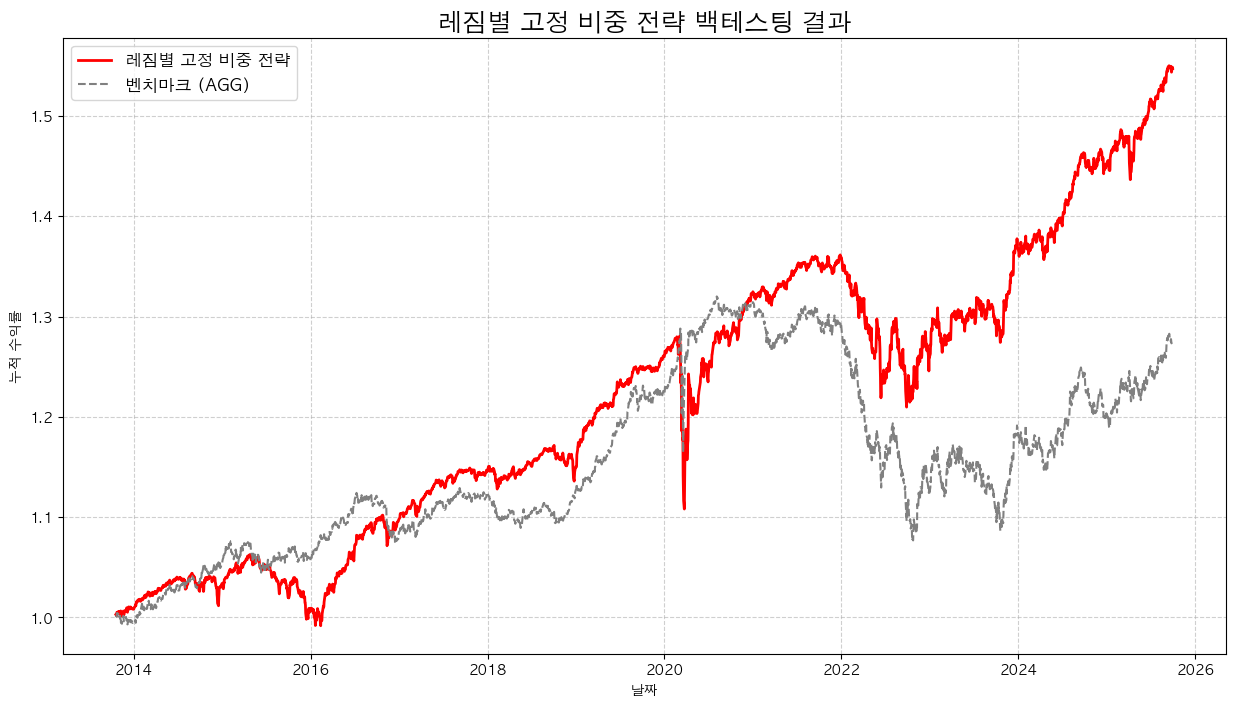

In [38]:
# --- 1단계: 데이터 준비 ---
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
from scipy.optimize import minimize

# 한글 폰트 설정
try:
    import platform
    if platform.system() == 'Darwin': plt.rc('font', family='AppleGothic')
    elif platform.system() == 'Windows': plt.rc('font', family='Malgun Gothic')
    else: plt.rc('font', family='NanumGothic')
except ImportError: pass
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로딩
tickers = ['SHYG', 'HYG', 'IEF', 'TLT', 'AGG']
start_date = '2007-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']
etf_data['HY_Price'] = etf_data['SHYG'].combine_first(etf_data['HYG'])

# FRED API 키를 입력하세요
api_key = 'f75d683dda2053416b64caae44e1bfb2'
fred = Fred(api_key=api_key)
oas_data = fred.get_series('BAMLH0A0HYM2', start_date=start_date, end_date=end_date)
oas_data.name = 'OAS'

# 데이터 통합 및 전처리
df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()
daily_returns = df[['HY_Price', 'IEF', 'TLT', 'AGG']].pct_change().dropna()

print("--- 1. 데이터 준비 완료 ---")


# --- 2단계: '초기 포트폴리오' 최적화 (Neutral Position) ---
DURATIONS = {'SHYG': 2.1, 'IEF': 7.03}

def optimize_neutral_portfolio(returns):
    num_assets = returns.shape[1]
    def objective(weights):
        portfolio_return = np.sum(returns.mean() * weights) * 252
        portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
        return -portfolio_return / portfolio_vol
    def duration_constraint(weights):
        portfolio_duration = np.sum(np.array([DURATIONS['SHYG'], DURATIONS['IEF']]) * weights)
        return portfolio_duration
    cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1},{'type': 'ineq', 'fun': lambda x: duration_constraint(x) - 3},{'type': 'ineq', 'fun': lambda x: 5 - duration_constraint(x)})
    bounds = tuple((0, 1) for _ in range(num_assets))
    initial_weights = np.array(num_assets * [1. / num_assets])
    result = minimize(objective, initial_weights, method='SLSQP', bounds=bounds, constraints=cons)
    return result.x

neutral_weights = optimize_neutral_portfolio(daily_returns[['HY_Price', 'IEF']])
neutral_duration = np.sum(np.array([DURATIONS['SHYG'], DURATIONS['IEF']]) * neutral_weights)
print(f"\n--- 2. 초기 포트폴리오 최적화 완료 (듀레이션: {neutral_duration:.2f}년) ---")


# --- 3단계: 레짐 신호 및 '고정 목표 비중' 생성 ---
signals_df = pd.DataFrame(index=df.index)
signals_df['OAS_Z'] = (df['OAS'] - df['OAS'].mean()) / df['OAS'].std()
vol_hy = daily_returns['HY_Price'].rolling(63).std()
vol_ief = daily_returns['IEF'].rolling(63).std()
signals_df['Credit_Volatility'] = vol_hy / vol_ief
signals_df.dropna(inplace=True)

df_monthly = signals_df.resample('ME').last()

# 4단계 레짐 정의
def calculate_4_regimes(oas_z, credit_vol, p50_oas, p80_oas, p80_vol):
    if oas_z > p80_oas and credit_vol > p80_vol: return 4
    elif oas_z > p80_oas: return 3
    elif oas_z > p50_oas: return 2
    else: return 1
p50_oas, p80_oas = signals_df['OAS_Z'].quantile([0.5, 0.8])
p80_vol = signals_df['Credit_Volatility'].quantile(0.8)
df_monthly['Regime'] = [calculate_4_regimes(row['OAS_Z'], row['Credit_Volatility'], p50_oas, p80_oas, p80_vol) for _, row in df_monthly.iterrows()]

# 레짐별 고정 비중 맵핑
regime_weight_map = {
    1: [0.9, 0.1, 0.0], # Very Risk-on
    2: [0.7, 0.3, 0.0], # Risk-on
    3: [0.6, 0.3, 0.1], # Risk-off
    4: [0.5, 0.0, 0.5]  # Very Risk-off
}
df_monthly['Target_Weights'] = df_monthly['Regime'].map(regime_weight_map)
df_monthly['Target_Weights'] = df_monthly['Target_Weights'].shift(1)

print("\n--- 3. 월별 레짐 및 고정 목표 비중 생성 완료 ---")


# --- 4단계: 월별 리밸런싱 백테스팅 ---
transaction_cost = 0.001
initial_capital = 1.0
capital = initial_capital
current_weights = np.array([neutral_weights[0], neutral_weights[1], 0.0]) # 초기 비중을 최적화된 Neutral로 설정
portfolio_values = []
dates = []

for date, row in daily_returns.iterrows():
    if date.is_month_start:
        target_weights = df_monthly.get(date.to_period('M').to_timestamp('M'), {}).get('Target_Weights')
        if isinstance(target_weights, list):
            target_weights_arr = np.array(target_weights)
            trade_cost = np.sum(np.abs(current_weights - target_weights_arr)) * transaction_cost
            capital *= (1 - trade_cost)
            current_weights = target_weights_arr

    daily_return = np.sum(row[['HY_Price', 'IEF', 'TLT']] * current_weights)
    if pd.notna(daily_return):
        capital *= (1 + daily_return)
        portfolio_values.append(capital)
        dates.append(date)

strategy_df = pd.DataFrame({'Strategy': portfolio_values}, index=pd.to_datetime(dates))
benchmark_df = (1 + daily_returns['AGG']).cumprod()
final_df = strategy_df.join(benchmark_df.rename('Benchmark'), how='inner')
print("\n--- 4. 백테스팅 완료 ---")


# --- 5단계: 성과 분석 및 시각화 ---
def calculate_performance_metrics(returns_series):
    if returns_series.empty: return {k: 0 for k in ['CAGR (%)', 'Volatility (%)', 'Sharpe Ratio', 'MDD (%)', 'Calmar Ratio']}
    days = len(returns_series); trading_days_per_year = 252
    total_return_ratio = returns_series.iloc[-1] / returns_series.iloc[0]
    if total_return_ratio <= 0: cagr = np.nan
    else: cagr = total_return_ratio ** (trading_days_per_year / days) - 1
    annualized_vol = returns_series.pct_change().std() * np.sqrt(trading_days_per_year)
    sharpe_ratio = cagr / annualized_vol if annualized_vol != 0 else np.nan
    mdd = (returns_series / returns_series.expanding(min_periods=1).max() - 1).min()
    calmar_ratio = cagr / abs(mdd) if mdd != 0 else np.nan
    return {'CAGR (%)': cagr*100, 'Volatility (%)': annualized_vol*100, 'Sharpe Ratio': sharpe_ratio, 'MDD (%)': mdd*100, 'Calmar Ratio': calmar_ratio}

metrics = pd.DataFrame({
    '레짐별 고정 비중 전략': calculate_performance_metrics(final_df['Strategy']),
    '벤치마크 (AGG)': calculate_performance_metrics(final_df['Benchmark'])
}).T
print("\n--- 5. 최종 성과 지표 비교 ---")
print(metrics.round(2))

plt.figure(figsize=(15, 8))
plt.plot(final_df.index, final_df['Strategy'], label='레짐별 고정 비중 전략', linewidth=2, color='red')
plt.plot(final_df.index, final_df['Benchmark'], label='벤치마크 (AGG)', linestyle='--', color='gray')
plt.title('레짐별 고정 비중 전략 백테스팅 결과', fontsize=18)
plt.xlabel('날짜'); plt.ylabel('누적 수익률')
plt.legend(fontsize=12); plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [39]:
metrics.round(2)

,CAGR (%),Volatility (%),Sharpe Ratio,MDD (%),Calmar Ratio
레짐별 고정 비중 전략,3.70,4.98,0.74,-13.48,0.27
벤치마크 (AGG),2.05,5.09,0.40,-18.43,0.11


/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_7711/1373333653.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  5 of 5 completed

/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_7711/1373333653.py:30: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()
/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_7711/1373333653.py:30: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()


--- 1. 데이터 준비 완료 ---

--- 2. Neutral 포트폴리오 최적화 완료 (듀레이션: 3.33년) ---

--- 3. 월별 레짐 신호 생성 완료 ---

--- 4. 백테스팅 완료 ---

--- 5. 최종 성과 지표 비교 ---
             CAGR (%)  Volatility (%)  Sharpe Ratio  MDD (%)  Calmar Ratio
전술적 듀레이션 틸트      1.90            5.68          0.33   -20.77          0.09
고정 듀레이션          3.70            4.98          0.74   -13.48          0.27
벤치마크 (AGG)       2.05            5.09          0.40   -18.43          0.11

--- 4. 백테스팅 완료 ---

--- 5. 최종 성과 지표 비교 ---
             CAGR (%)  Volatility (%)  Sharpe Ratio  MDD (%)  Calmar Ratio
전술적 듀레이션 틸트      1.90            5.68          0.33   -20.77          0.09
고정 듀레이션          3.70            4.98          0.74   -13.48          0.27
벤치마크 (AGG)       2.05            5.09          0.40   -18.43          0.11


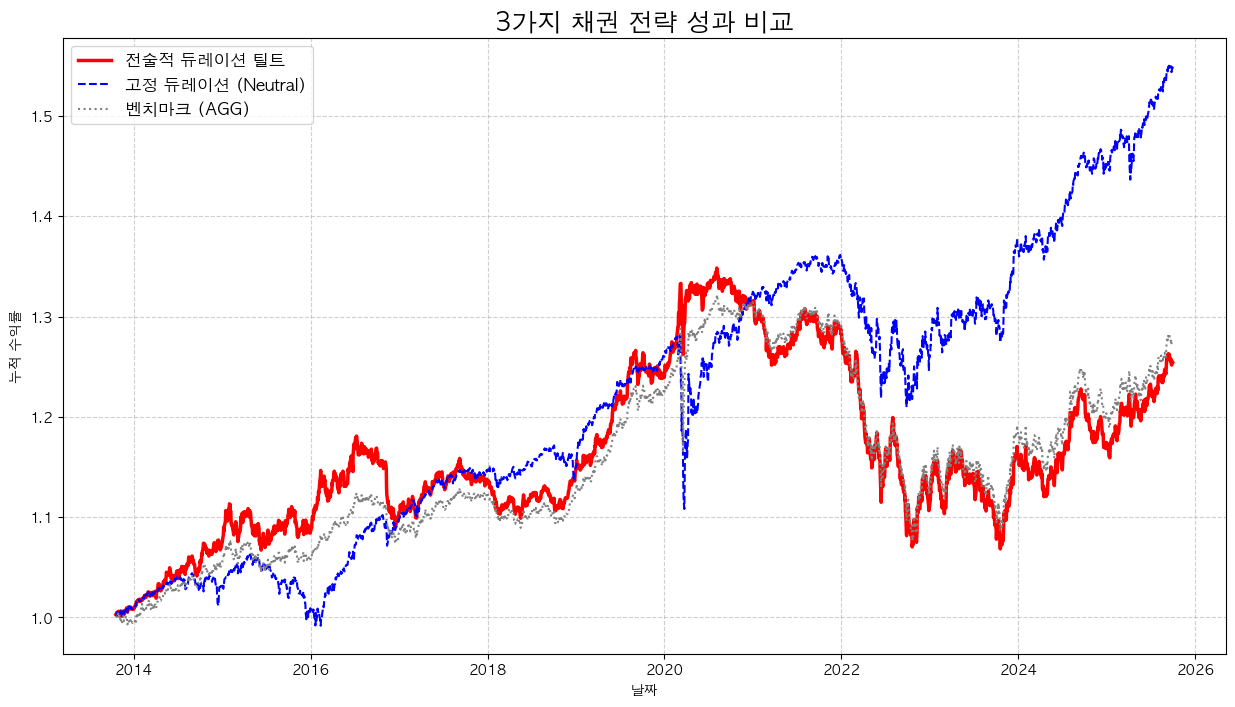

In [42]:
# --- 1단계: 데이터 준비 ---
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
from scipy.optimize import minimize

# 한글 폰트 설정
try:
    import platform
    if platform.system() == 'Darwin': plt.rc('font', family='AppleGothic')
    elif platform.system() == 'Windows': plt.rc('font', family='Malgun Gothic')
    else: plt.rc('font', family='NanumGothic')
except ImportError: pass
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로딩
tickers = ['SHYG', 'HYG', 'IEF', 'TLT', 'AGG']
start_date = '2007-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']
etf_data['HY_Price'] = etf_data['SHYG'].combine_first(etf_data['HYG'])

# FRED API 키를 입력하세요
api_key = 'f75d683dda2053416b64caae44e1bfb2'
fred = Fred(api_key=api_key)
oas_data = fred.get_series('BAMLH0A0HYM2', start_date=start_date, end_date=end_date)
oas_data.name = 'OAS'
df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()
daily_returns = df[['HY_Price', 'IEF', 'TLT', 'AGG']].pct_change().dropna()
print("--- 1. 데이터 준비 완료 ---")


# --- 2단계: Neutral 포트폴리오 최적화 ---
DURATIONS = {'SHYG': 2.1, 'IEF': 7.03}
def optimize_neutral_portfolio(returns):
    num_assets = returns.shape[1]
    def objective(weights):
        portfolio_return = np.sum(returns.mean() * weights) * 252
        portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
        return -portfolio_return / portfolio_vol
    def duration_constraint(weights):
        portfolio_duration = np.sum(np.array([DURATIONS['SHYG'], DURATIONS['IEF']]) * weights)
        return portfolio_duration
    cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1},{'type': 'ineq', 'fun': lambda x: duration_constraint(x) - 3},{'type': 'ineq', 'fun': lambda x: 5 - duration_constraint(x)})
    bounds = tuple((0, 1) for _ in range(num_assets))
    initial_weights = np.array(num_assets * [1. / num_assets])
    result = minimize(objective, initial_weights, method='SLSQP', bounds=bounds, constraints=cons)
    return result.x
neutral_weights = optimize_neutral_portfolio(daily_returns[['HY_Price', 'IEF']])
neutral_duration = np.sum(np.array([DURATIONS['SHYG'], DURATIONS['IEF']]) * neutral_weights)
print(f"\n--- 2. Neutral 포트폴리오 최적화 완료 (듀레이션: {neutral_duration:.2f}년) ---")


# --- 3단계: 레짐 신호 및 '목표 듀레이션' 생성 ---
signals_df = pd.DataFrame(index=df.index)
signals_df['OAS_Z'] = (df['OAS'] - df['OAS'].mean()) / df['OAS'].std()
vol_hy = daily_returns['HY_Price'].rolling(63).std()
vol_ief = daily_returns['IEF'].rolling(63).std()
signals_df['Credit_Volatility'] = vol_hy / vol_ief
signals_df.dropna(inplace=True)
df_monthly = signals_df.resample('ME').last()
def calculate_regime(oas_z, credit_vol, p80_oas, p80_vol):
    if oas_z > p80_oas and credit_vol > p80_vol: return 4
    elif oas_z > p80_oas: return 3
    else: return 2
p80_oas = signals_df['OAS_Z'].quantile(0.8)
p80_vol = signals_df['Credit_Volatility'].quantile(0.8)
df_monthly['Regime'] = [calculate_regime(row['OAS_Z'], row['Credit_Volatility'], p80_oas, p80_vol) for _, row in df_monthly.iterrows()]
BENCHMARK_DURATION_PROXY = 6.2
regime_duration_map = {2: 1.0, 3: 1.1, 4: 1.2}
df_monthly['Target_Duration'] = df_monthly['Regime'].map(regime_duration_map) * BENCHMARK_DURATION_PROXY
df_monthly['Target_Duration'] = df_monthly['Target_Duration'].shift(1)
print("\n--- 3. 월별 레짐 신호 생성 완료 ---")


# --- 4단계: 3가지 전략 백테스팅 실행 (오류 수정) ---
DURATIONS_FULL = {'SHYG': 2.1, 'IEF': 7.03, 'TLT': 17.0}
transaction_cost = 0.001

def calculate_weights_for_duration(target_dur):
    if pd.isna(target_dur): return None
    if target_dur <= DURATIONS_FULL['IEF']:
        w_ief = (target_dur - DURATIONS_FULL['SHYG']) / (DURATIONS_FULL['IEF'] - DURATIONS_FULL['SHYG'])
        w_ief = np.clip(w_ief, 0, 1)
        return np.array([1 - w_ief, w_ief, 0.0])
    else:
        w_tlt = (target_dur - DURATIONS_FULL['IEF']) / (DURATIONS_FULL['TLT'] - DURATIONS_FULL['IEF'])
        w_tlt = np.clip(w_tlt, 0, 1)
        return np.array([0.0, 1 - w_tlt, w_tlt])

# 초기값 설정
tdt_capital, fd_capital = 1.0, 1.0
tdt_weights = np.array([neutral_weights[0], neutral_weights[1], 0.0])
fd_weights = np.array([neutral_weights[0], neutral_weights[1], 0.0])
tdt_values, fd_values = [], []

# 백테스팅 통합 루프
for date, row in daily_returns.iterrows():
    if date.is_month_start:
        # --- [수정된 부분 START] ---
        # 이번 달 거래를 위해 '지난달 말'의 신호를 안정적으로 조회
        previous_month_end = date - pd.DateOffset(days=1)
        target_duration = None
        if previous_month_end in df_monthly.index:
            target_duration = df_monthly.loc[previous_month_end, 'Target_Duration']
        # --- [수정된 부분 END] ---

        # TDT 리밸런싱
        if pd.notna(target_duration):
            target_weights = calculate_weights_for_duration(target_duration)
            trade_cost = np.sum(np.abs(tdt_weights - target_weights)) * transaction_cost
            tdt_capital *= (1 - trade_cost)
            tdt_weights = target_weights
            
        # FD 리밸런싱
        fd_target_weights = np.array([neutral_weights[0], neutral_weights[1], 0.0])
        fd_trade_cost = np.sum(np.abs(fd_weights - fd_target_weights)) * transaction_cost
        fd_capital *= (1 - fd_trade_cost)
        fd_weights = fd_target_weights

    # 일일 수익률 계산
    tdt_return = np.sum(row[['HY_Price', 'IEF', 'TLT']] * tdt_weights)
    if pd.notna(tdt_return): tdt_capital *= (1 + tdt_return)
    
    fd_return = np.sum(row[['HY_Price', 'IEF']] * fd_weights[:2])
    if pd.notna(fd_return): fd_capital *= (1 + fd_return)
        
    tdt_values.append(tdt_capital)
    fd_values.append(fd_capital)

# 최종 결과 데이터프레임
final_df = pd.DataFrame({'Tactical_Duration': tdt_values, 'Fixed_Duration': fd_values}, index=daily_returns.index)
benchmark_df = (1 + daily_returns['AGG']).cumprod()
final_df = final_df.join(benchmark_df.rename('Benchmark'), how='inner')
print("\n--- 4. 백테스팅 완료 ---")


# --- 5단계: 성과 분석 및 시각화 ---
def calculate_performance_metrics(returns_series):
    if returns_series.empty: return {k: 0 for k in ['CAGR (%)', 'Volatility (%)', 'Sharpe Ratio', 'MDD (%)', 'Calmar Ratio']}
    days = len(returns_series); trading_days_per_year = 252
    total_return_ratio = returns_series.iloc[-1] / returns_series.iloc[0]
    if total_return_ratio <= 0: cagr = np.nan
    else: cagr = total_return_ratio ** (trading_days_per_year / days) - 1
    annualized_vol = returns_series.pct_change().std() * np.sqrt(trading_days_per_year)
    sharpe_ratio = cagr / annualized_vol if annualized_vol != 0 else np.nan
    mdd = (returns_series / returns_series.expanding(min_periods=1).max() - 1).min()
    calmar_ratio = cagr / abs(mdd) if mdd != 0 else np.nan
    return {'CAGR (%)': cagr*100, 'Volatility (%)': annualized_vol*100, 'Sharpe Ratio': sharpe_ratio, 'MDD (%)': mdd*100, 'Calmar Ratio': calmar_ratio}

metrics = pd.DataFrame({
    '전술적 듀레이션 틸트': calculate_performance_metrics(final_df['Tactical_Duration']),
    '고정 듀레이션': calculate_performance_metrics(final_df['Fixed_Duration']),
    '벤치마크 (AGG)': calculate_performance_metrics(final_df['Benchmark'])
}).T
print("\n--- 5. 최종 성과 지표 비교 ---")
print(metrics.round(2))

plt.figure(figsize=(15, 8))
plt.plot(final_df.index, final_df['Tactical_Duration'], label='전술적 듀레이션 틸트', linewidth=2.5, color='red')
plt.plot(final_df.index, final_df['Fixed_Duration'], label='고정 듀레이션 (Neutral)', linewidth=1.5, linestyle='--', color='blue')
plt.plot(final_df.index, final_df['Benchmark'], label='벤치마크 (AGG)', linestyle=':', color='gray')
plt.title('3가지 채권 전략 성과 비교', fontsize=18)
plt.xlabel('날짜'); plt.ylabel('누적 수익률')
plt.legend(fontsize=12); plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [43]:
metrics.round(2)

,CAGR (%),Volatility (%),Sharpe Ratio,MDD (%),Calmar Ratio
전술적 듀레이션 틸트,1.90,5.68,0.33,-20.77,0.09
고정 듀레이션,3.70,4.98,0.74,-13.48,0.27
벤치마크 (AGG),2.05,5.09,0.40,-18.43,0.11
